<a href="https://colab.research.google.com/github/Caory2/Teoria_de_Aprendizaje_de_Maquina/blob/main/TAREA_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje no supervisado

# Ejercicios

Para los siguientes puntos, utilizar la librería [RAPIDS](https://rapids.ai/) a la hora de implementar los algoritmos estudiados, en caso de estar disponibles.

- Realice una comparación de los métodos de clustering vistos, para generar una segmentación de imagen a color, incluyendo la información de ubicación de cada pixel (ver Cuaderno guía [tanjiro](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/4_Clasificacion_Clustering_DR/tanjiro.ipynb)). Varie la cantidad de grupos (niveles o clases de segmentación) $k\in\{3,5,7,9\}$ y presente los scores de inercia y silueta conseguidos.

- Repita el punto anterior realizando una proyección 2D de los datos con PCA y UMAP (ver guía [reducción de dimensión](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/4_Clasificacion_Clustering_DR/8_ReduccionDimension.ipynb))
 antes de generar las segmentaciones.

In [6]:
from IPython.display import clear_output

# Importar todas las librerias necesarias instalando RAPIDS en el entorno Colab
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py



import cv2
import cudf
import cupy as cp # Importar cupy
import numpy as np
import matplotlib.pyplot as plt
from cuml.cluster import KMeans, DBSCAN
from sklearn.cluster import SpectralClustering
from cuml.metrics.cluster import silhouette_score

clear_output()

In [7]:
from google.colab import files
from PIL import Image

# Subir archivo
uploaded = files.upload()

# Cargar la imagen (usa el nombre real del archivo subido)
img = Image.open('338fdfcc425fca09ef4c43bbc766a7d45d5ff98c64a5668486bb0cd2ab62e2f2 (1).jpg')

# Mostrar la imagen
img.show()


Saving 338fdfcc425fca09ef4c43bbc766a7d45d5ff98c64a5668486bb0cd2ab62e2f2 (1).jpg to 338fdfcc425fca09ef4c43bbc766a7d45d5ff98c64a5668486bb0cd2ab62e2f2 (1) (1).jpg


(760, 760, 3)

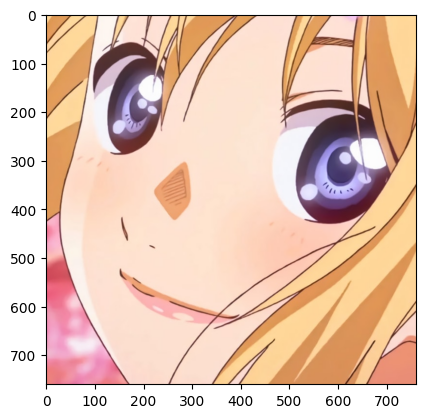

In [8]:
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np
image = imread(os.path.join("338fdfcc425fca09ef4c43bbc766a7d45d5ff98c64a5668486bb0cd2ab62e2f2 (1).jpg"))
image = image[40:800,40:800,:]
plt.imshow(image)
image.shape

In [9]:
X = image.reshape(-1, 3) # Remodela la imagen en un arreglo 2D donde cada fila representa un píxel y las 3 columnas son los valores de color (R, G, B). -1 infiere el número de filas automáticamente.
r,c,ch = image.shape # Desempaqueta las dimensiones de la imagen en las variables r
print(r,c,ch) # Imprime los valores de r, c y ch.

760 760 3


In [10]:
vr = np.linspace(0,r,r,endpoint=False)
vc = np.linspace(0,c,c,endpoint=False)
Xc = np.kron(np.ones((r,1)),vc.reshape(-1,1))
Xr = np.kron(vr.reshape(-1,1),np.ones((1,c)))
Xc = Xc.reshape(-1)
Xr = Xr.reshape(-1)
X = np.c_[X,Xc,Xr]
X.shape

(577600, 5)

In [11]:
# Convertir los datos a formato CuPy para usar RAPIDS
X_gpu = cp.asarray(X)

# Valores de k a probar
k_values = [3, 5, 7, 9]
kmeans_results = {}

for k in k_values:
    print(f"Ejecutando K-Means para k = {k}")
    # Inicializar y entrenar el modelo K-Means con cuML (RAPIDS)
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    kmeans.fit(X_gpu)

    # Obtener las etiquetas predichas
    labels = kmeans.labels_

    # Calcular la inercia
    inertia = kmeans.inertia_

    # Calcular el silhouette score (convertir labels a numpy para scikit-learn si cuML no lo sopporta directamente)
    # cuML tiene silhouette_score, lo usaremos directamente
    silhouette_avg = silhouette_score(X_gpu, labels)

    kmeans_results[k] = {
        'model': kmeans,
        'inertia': inertia,
        'silhouette_score': silhouette_avg,
        'labels': labels
    }
    print(f"k = {k}: Inercia = {inertia:.2f}, Silhouette Score = {silhouette_avg:.2f}")

Ejecutando K-Means para k = 3
k = 3: Inercia = 26399424693.59, Silhouette Score = 0.34
Ejecutando K-Means para k = 5
k = 5: Inercia = 15582717956.19, Silhouette Score = 0.35
Ejecutando K-Means para k = 7
k = 7: Inercia = 12079655647.93, Silhouette Score = 0.32
Ejecutando K-Means para k = 9
k = 9: Inercia = 9650337499.90, Silhouette Score = 0.32


In [12]:
# Aplicar DBSCAN a los datos originales (X_gpu)
# Es importante ajustar los parámetros eps y min_samples
# Vamos a empezar con valores de ejemplo y luego puedes ajustarlos
dbscan = DBSCAN(eps=100, min_samples=50) # Ajusta estos valores según tus datos
labels_db = dbscan.fit_predict(X_gpu)

# Calcular la puntuación de silueta
# Asegúrate de que hay más de un cluster (-1 es ruido)
if len(cp.unique(labels_db)) > 1:
    sil_db = silhouette_score(X_gpu, labels_db)
    print(f"DBSCAN Silhouette Score: {sil_db:.2f}")
else:
    print("DBSCAN encontró solo un cluster o solo ruido. Ajusta los parámetros eps y min_samples.")

# Almacenar los resultados de DBSCAN para comparación
dbscan_result_original = {
    'model': dbscan,
    'silhouette_score': sil_db if len(cp.unique(labels_db)) > 1 else None,
    'labels': labels_db
}

[2025-10-29 21:23:33.159] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 4375 -> 3717. Using the larger integer type might result in better performance
DBSCAN encontró solo un cluster o solo ruido. Ajusta los parámetros eps y min_samples.


In [13]:
# Presentar los scores de inercia y silueta
print("\nResultados de K-Means para diferentes valores de k:")
print("----------------------------------------------------")
print("  k  |   Inercia   | Silhouette Score")
print("-----|-------------|------------------")
for k, result in kmeans_results.items():
    print(f"  {k}  | {result['inertia']:<11.2f} | {result['silhouette_score']:<16.2f}")

# Presentar el score de silueta para DBSCAN (si se calculó)
print("\nResultado de DBSCAN:")
print("--------------------")
if dbscan_result_original and dbscan_result_original['silhouette_score'] is not None:
    print(f"Silhouette Score: {dbscan_result_original['silhouette_score']:.2f}")
else:
    print("No se pudo calcular el Silhouette Score para DBSCAN. Asegúrate de que encontró más de un cluster.")


Resultados de K-Means para diferentes valores de k:
----------------------------------------------------
  k  |   Inercia   | Silhouette Score
-----|-------------|------------------
  3  | 26399424693.59 | 0.34            
  5  | 15582717956.19 | 0.35            
  7  | 12079655647.93 | 0.32            
  9  | 9650337499.90 | 0.32            

Resultado de DBSCAN:
--------------------
No se pudo calcular el Silhouette Score para DBSCAN. Asegúrate de que encontró más de un cluster.


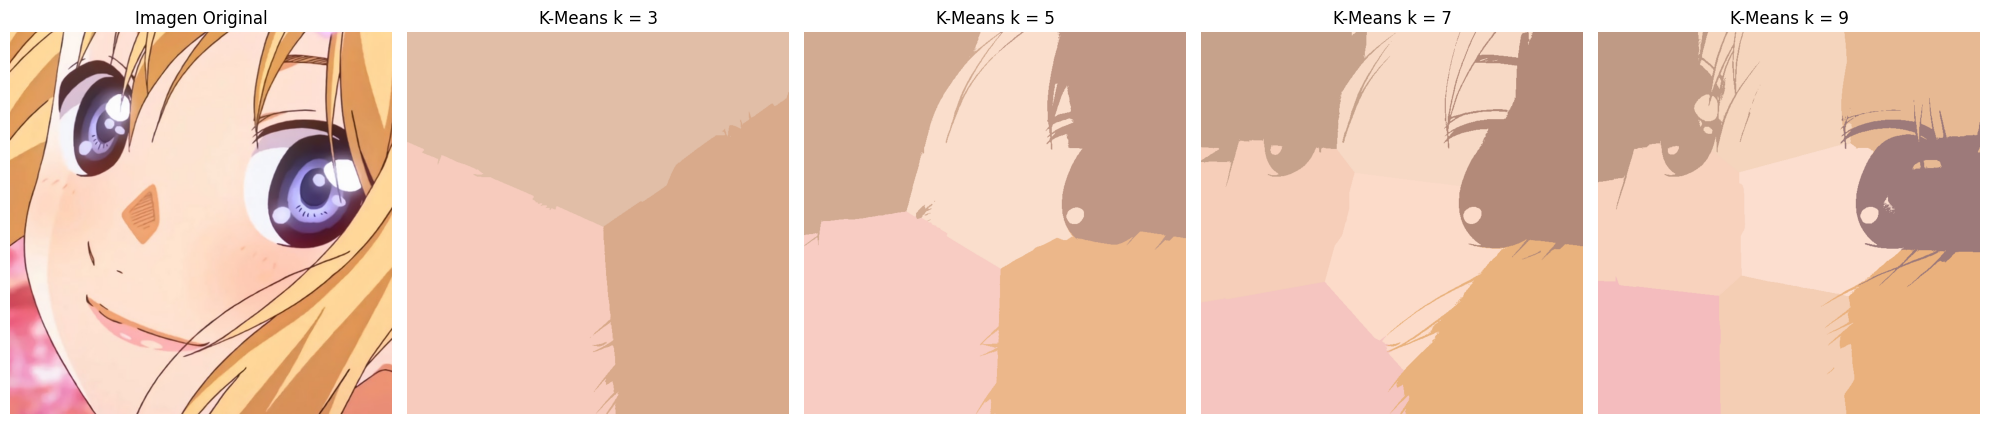

In [14]:
# Assuming kmeans_results is defined from clustering on the combined data

# Prepare data for visualization
r, c, ch = image.shape # Get original image dimensions

# Dictionary to store K-Means segmented images
kmeans_segmented_images_combined = {}
k_values = sorted(kmeans_results.keys()) # Get k values from results

# Generate K-Means segmented images using stored results
for k in k_values:
    # Get labels and centroids from the stored results
    labels_np = cp.asnumpy(kmeans_results[k]['labels'])
    centroids_np = cp.asnumpy(kmeans_results[k]['model'].cluster_centers_)

    segmented_image_labels = labels_np.reshape(r, c)
    segmented_image = np.zeros((r, c, 3), dtype=np.uint8)

    # Note: Centroids here are for the combined features (color, location, PCA, UMAP).
    # For image visualization, we only use the first 3 features (color) from the centroid.
    for i in range(r):
        for j in range(c):
            cluster_label = segmented_image_labels[i, j]
            # Ensure centroid color values are within the valid range [0, 255] for uint8
            # Use only the first 3 elements of the centroid (corresponding to RGB)
            segmented_image[i, j, :] = centroids_np[cluster_label, :3].astype(np.uint8)

    kmeans_segmented_images_combined[k] = segmented_image

# Visualize original and K-Means segmented images
plt.figure(figsize=(20, 5))

# Original Image
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(image)
plt.title("Imagen Original")
plt.axis('off')

# K-Means Segmented Images
for i, k in enumerate(k_values):
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(kmeans_segmented_images_combined[k])
    plt.title(f"K-Means k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# SEGUNDO PUNTO

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import umap

# Assuming X contains color and location data from previous cells

# Scale the data (important for PCA and UMAP)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Apply UMAP for dimensionality reduction to 2 components
# Use a random_state for reproducibility
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1) # Example UMAP parameters
X_umap = umap_model.fit_transform(X_scaled)

print("Reducción de dimensionalidad con PCA y UMAP aplicada.")
print("Variables X_pca y X_umap creadas.")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
